# Финальный проект модуля "Продуктовая аналитика"


## Структура таблиц

 1) olist_customers_dataset.csv — таблица с уникальными идентификаторами пользователей
- customer_id — позаказный идентификатор пользователя

- customer_unique_id — уникальный идентификатор пользователя (аналог номера паспорта)

- customer_zip_code_prefix — почтовый индекс пользователя

- customer_city — город доставки пользователя

- customer_state — штат доставки пользователя

2) olist_orders_dataset.csv —  таблица заказов
- order_id — уникальный идентификатор заказа (номер чека)

- customer_id — позаказный идентификатор пользователя

- order_status — статус заказа

- order_purchase_timestamp — время создания заказа

- order_approved_at — время подтверждения оплаты заказа

- order_delivered_carrier_date — время передачи заказа в логистическую службу

- order_delivered_customer_date — время доставки заказа

- order_estimated_delivery_date — обещанная дата доставки

3) olist_order_items_dataset.csv — товарные позиции, входящие в заказы
- order_id — уникальный идентификатор заказа (номер чека)

- order_item_id — идентификатор товара внутри одного заказа

- product_id — ид товара (аналог штрихкода)

- seller_id — ид производителя товара

- shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике

- price — цена за единицу товара

- freight_value — вес товара 

## Уникальные статусы заказов в таблице olist_orders_dataset:

- created — создан;
- approved — подтверждён;
- invoiced — выставлен счёт;
- processing — в процессе сборки заказа;
- shipped — отгружён со склада;
- delivered — доставлен пользователю;
- unavailable — заказ отменён по причине недоступности товара;;
- canceled — отменён.

In [91]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors

## Просмотр и обработка данных

In [92]:
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')

In [93]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [94]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [95]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Изменения типа данных для дат 

In [96]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])


In [97]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](4), object(4)
memory usage: 6.1+ MB


In [98]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Дату подтверждения заказа можно заполнить временем покупки, возможно она не отразилась в данных по техническим причинам.

In [99]:
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])

Так как для анализа нас интересуют доставленные заказы, то удаляем заказы без даты доставки

In [100]:
orders = orders.dropna(subset=['order_delivered_customer_date'])

In [101]:
orders.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     1
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [102]:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [103]:
order_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [104]:
orders.nunique()

order_id                         96476
customer_id                      96476
order_status                         2
order_purchase_timestamp         95954
order_approved_at                88287
order_delivered_carrier_date     80112
order_delivered_customer_date    95664
order_estimated_delivery_date      445
dtype: int64

In [105]:
customers.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

In [106]:
order_items.nunique()

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

# Задание 1

## Когортный анализ. Оценка месячного retention

Мы считаем retention только для заказов со статусом 'delivered'

In [107]:
orders['order_purchase_timestamp'].describe()

/tmp/ipykernel_51/3978380587.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  orders['order_purchase_timestamp'].describe()


count                   96476
unique                  95954
top       2018-08-02 12:06:09
freq                        3
first     2016-09-15 12:16:38
last      2018-08-29 15:00:37
Name: order_purchase_timestamp, dtype: object

In [108]:
orders[['order_purchase_timestamp', 'order_delivered_customer_date']].isna().sum()

order_purchase_timestamp         0
order_delivered_customer_date    0
dtype: int64

In [109]:
orders.shape

(96476, 8)

In [110]:
retention_df = orders.merge(customers, on='customer_id')

In [111]:
retention_df = retention_df.query('order_status == "delivered"')[['customer_unique_id', 'order_id', 'order_purchase_timestamp']]

In [112]:
retention_df.head()

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39


In [113]:
# Извлекаем месяц заказа
retention_df['order_period'] = retention_df['order_purchase_timestamp'].dt.to_period('M')


In [114]:
# Присваиваем когорты на основе даты первого действия для каждого пользователя
retention_df['cohort'] = retention_df.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')


In [115]:
# Рассчитываем номер периода в днях 
retention_df['period_number_month'] = retention_df['order_period'].astype(int) - retention_df['cohort'].astype(int)

In [116]:
retention_df['period_number_month'].value_counts()

0     94571
1       433
2       283
3       202
4       181
5       149
6       133
7       103
8        88
10       75
9        63
11       59
12       36
13       27
14       25
15       18
17       10
16        9
19        3
20        2
Name: period_number_month, dtype: int64

In [117]:
# Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
df_cohort = retention_df.groupby(['cohort', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [118]:
df_cohort.head()

,cohort,period_number_month,n_customers
0,2016-09,0,1
1,2016-10,0,262
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1


In [119]:
# Создаем сводную таблицу для когортного анализа
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')

In [120]:
cohort_pivot.head()

period_number_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN


In [121]:

cohort_size = cohort_pivot.iloc[:, 0]

In [122]:
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
retention_matrix = retention_matrix.iloc[:, 1:]

In [123]:
retention_matrix.head()

period_number_month,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,
2016-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.007634
2016-12,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,0.002789,0.002789,0.001395,0.004184,0.001395,0.004184,0.001395,0.001395,NaN,0.004184,0.001395,0.006974,0.004184,0.001395,0.001395,0.002789,0.004184,0.001395,NaN
2017-02,0.001843,0.003071,0.001229,0.004300,0.001229,0.002457,0.001843,0.001229,0.001843,0.001229,0.003071,0.001229,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN


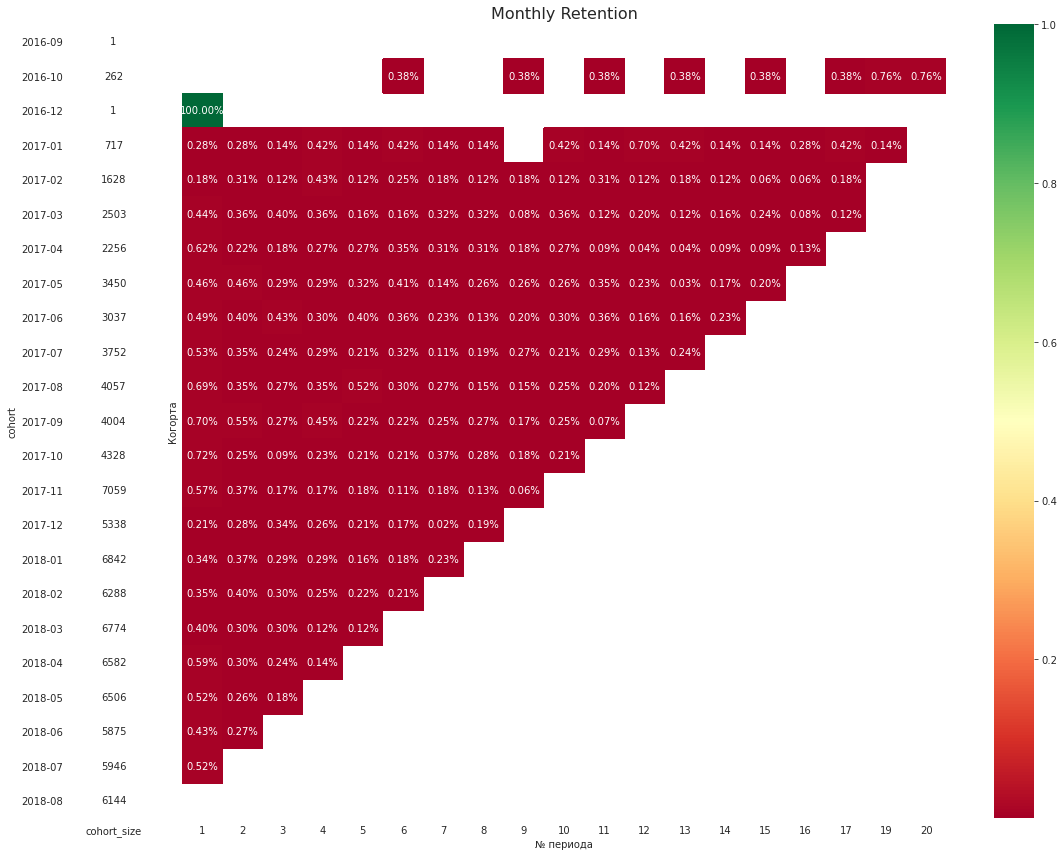

In [124]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.2%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

Медианный retention 1-го месяца

In [36]:
# Извлечение значений retention для первого месяца
first_month_retention = retention_matrix.iloc[:, 1]  # Первый столбец

# Расчет медианного значения
median_retention = first_month_retention.median()
round(median_retention*100, 2)

0.33

Когорта с самым высоким retention на 3-й месяц

In [41]:
third_month_retention = retention_matrix.iloc[:, 3]


In [42]:
third_month_retention = third_month_retention.dropna()


In [43]:
max_retention_index = third_month_retention.idxmax()
max_retention_index

Period('2017-09', 'M')

In [44]:
max_retention_value = third_month_retention.max()
round(max_retention_value * 100, 2)

0.45

Когорта 2017-06 показала максимальный retention на 3-й месяц - 0.45%

## Выводы

- Median retention 1-го месяца крайний низкий (0.33%). Покупатели не возвращаются после первого заказа;
- Retention на 3-й месяц остаётся низким - 0.45%

Пользователи не находят достаточной ценности в повторном использовании маркетплейса. Возможные причины: 
- долгая доставка;
- отмены заказа;
- ограниченный ассортимент;
- неудобная оплата.

# Задание 2

## Product/Market fit

Для оценки product/market fit используется усреднённая кривая retention по всем когортам пользователей

In [48]:
retention_mean = retention_matrix.iloc[:, :12].mean()

No handles with labels found to put in legend.


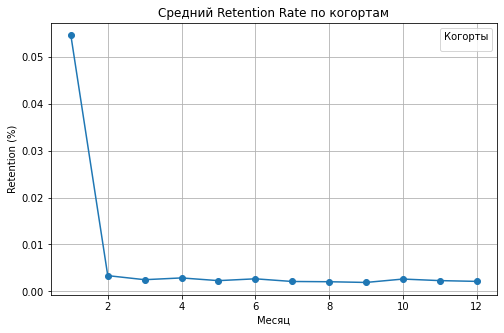

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(retention_mean.index, retention_mean.values, marker='o')

plt.title('Средний Retention Rate по когортам')
plt.xlabel('Месяц')
plt.ylabel('Retention (%)')
plt.legend(title='Когорты')
plt.grid()
plt.show()

## Выводы

Product/Market Fit показывает резкое падение после первого месяца и не выходит на плато в последующие периоды. Это говорит об отсутствии устойчивого интереса пользователей и указывает на слабый product/market fit продукта.

Маркетплейс должен сосердоточиться на повышении retention и увеличении частоты покупок. 
Причины отсутствия Product/Market Fit:
- клиенты совершают разовые покупки;
- слабая программа возврата клиентов;
- сильная конкуренция с другими маркетплейсами

# Задание 3

## 5 основных метрик

1) GMV (Gross Merchandise Value) - рост объема продаж 

In [50]:
sales = orders.merge(order_items, on='order_id')
sales = sales.query("order_status == 'delivered'")
sales['order_month'] = sales['order_purchase_timestamp'].dt.to_period('M')

In [51]:
gmv = sales.groupby('order_month').agg(gmv=('price', 'sum')).reset_index()


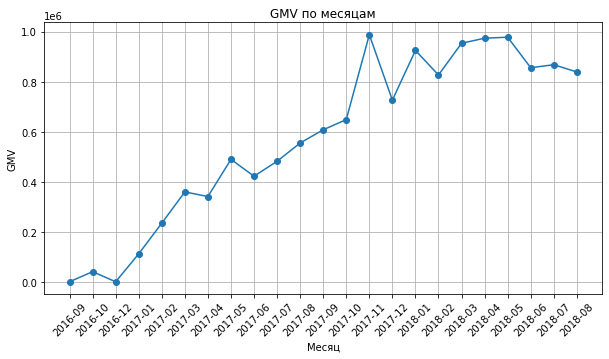

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(gmv['order_month'].astype(str), gmv['gmv'], marker='o')

plt.title('GMV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('GMV')
plt.xticks(rotation=45)
plt.grid()
plt.show()

2) MAU (Monthly Active Users) - объем аудитории

In [53]:
users = orders.merge(customers, on='customer_id')
users = users.query('order_status == "delivered"')
users['order_month'] = users['order_purchase_timestamp'].dt.to_period('M')

In [54]:
mau = users.groupby('order_month').agg(users=('customer_unique_id', 'nunique')).reset_index()


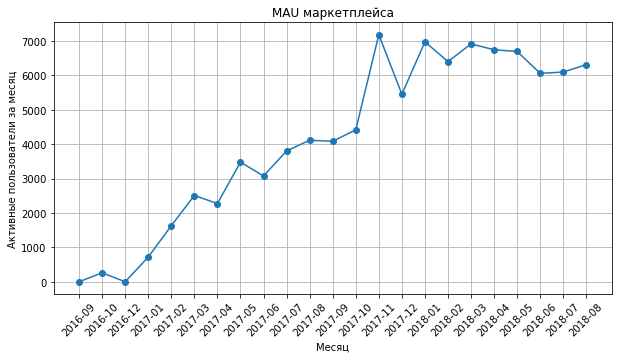

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(mau['order_month'].astype(str), mau['users'], marker='o')

plt.title('MAU маркетплейса')
plt.xlabel('Месяц')
plt.ylabel('Активные пользователи за месяц')
plt.xticks(rotation=45)
plt.grid()
plt.show()

3) Conversion Rate - интерес новых пользователей

Для расчёта метрики нужно общее число посетителей маркетплейса, но в предоставленных данных они отсутствуют.

4) Retention Rate - вовлечённость пользователей

In [87]:
# Получаем количество уникальных пользователей по месяцам
retention_users = users.groupby(['order_month', 'customer_unique_id']).size().reset_index()
rate = retention_users.groupby('order_month').agg(users=('customer_unique_id', 'nunique')).reset_index()
retention_rate = pd.DataFrame()


In [88]:
# Сдвигаем данные на один месяц, чтобы получить количество пользователей в предыдущем месяце
retention_rate['previous_month_users'] = rate['users'].shift(1)
retention_rate['current_month_users'] = rate['users']
# Рассчитываем retention rate
retention_rate['retention_rate'] = (retention_rate['current_month_users'] / retention_rate['previous_month_users']) * 100

In [89]:
# Объединяем с исходными данными
retention_rate['order_month'] = rate['order_month']
retention_rate = retention_rate[['order_month', 'retention_rate']]

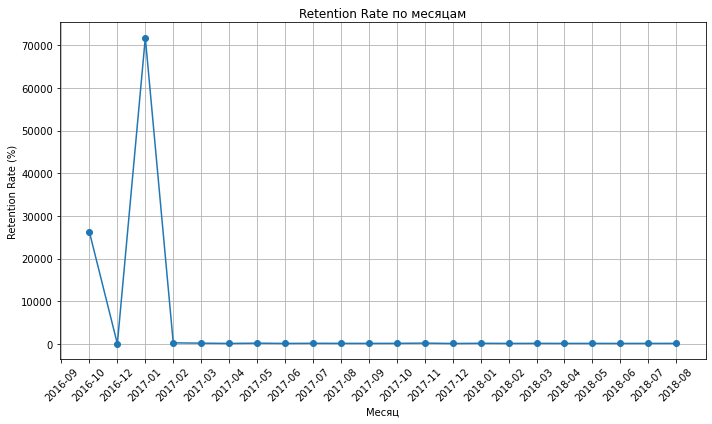

In [90]:
plt.figure(figsize=(10, 6))
plt.plot(retention_rate['order_month'].astype(str), retention_rate['retention_rate'], marker='o')
plt.title('Retention Rate по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Retention Rate (%)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

5) Average Revenue Per User - денежная вовлечённость

In [62]:
revenue = sales.groupby('order_month').agg(revenue=('price', 'sum')).reset_index()
arpu = revenue.merge(mau, on='order_month')

In [63]:
arpu['arpu'] = arpu['revenue'] / arpu['users']


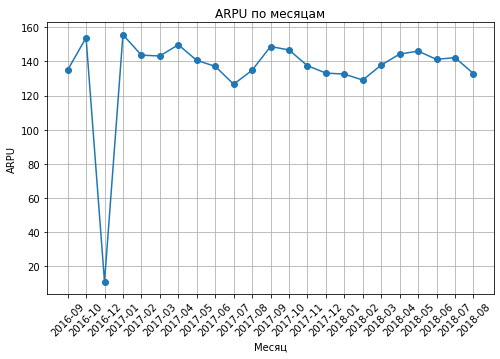

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(arpu['order_month'].astype(str), arpu['arpu'], marker='o')

plt.title('ARPU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ARPU')
plt.xticks(rotation=45)
plt.grid()
plt.show()

Маленькое количество пользователей за 11-2016 может быть связано с ошибкой в сборе данных. 

## Выводы


Главный фокус проекта: увеличение retention и повторных покупок. 

# Задача 4

## Выбор гипотез с помощью фреймворка ICE

1) Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

2) Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

3) Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [158]:
median_retention

0.005076336795178115

In [159]:
orders_june = orders.merge(customers, on='customer_id')
orders_june = orders_june.query('order_status == "delivered" and order_purchase_timestamp >= "2017-06-01"')

In [160]:
users = orders_june['customer_unique_id'].nunique()
users

82856

In [165]:
impact = users * median_retention
impact

420.6049615012779

Для перевода в Impact использовалась шкала из задания.

In [166]:
impact = [4, 4, 4]
confidence = [8, 10, 5]
ease = [6, 4, 9]

In [167]:
ice_scores = [

    impact[0] * confidence[0] * ease[0],

    impact[1] * confidence[1] * ease[1],

    impact[2] * confidence[2] * ease[2]
]

In [168]:
for i, ice in enumerate(ice_scores, start=1):

    print(f"ICE гипотезы {i}: {ice:.2f}")

ICE гипотезы 1: 192.00
ICE гипотезы 2: 160.00
ICE гипотезы 3: 180.00


## Выводы

У первой гипотезы наибольший ICE.


# Задание 5

## Метрики, на которые может повлиять гипотеза 

## Целевая метрика:


- конверсия в доставленный заказ 

Она напрямую связана с отменёнными заказами. При исправлении бага большая часть заказов будет доставлена успешна. Также данная метрика напрямую влияет на GMV и прибылль.

## Прокси метрика:


- коэффициент отмен (Cancel rate)

Данная метрика быстрее отреагирует на снижение отмен после исправления бага.

## Guardrail метрика:

- время доставки заказа 

Важно убедиться, что скорость доставки не снизилась, и процесс обработки заказов не замедлился.

# Задание 6

## Отчёт

## Формулировка проблемы

Исходя из когортного анализа, маркетплейс имеет крайне низкие показатели удержания пользователей. 

Медианный retention первого месяца составляет около 0.3%, что означает, что большинство пользователей совершают только одну покупку и не возвращаются на платформу. В то же время динамика активной аудитории (согласно MAU) обеспечивается притоком новых пользователей. Маркетплейс столкнулся с проблемой, когда пользователи совершают разовые покупки, что снижает долгосрочную ценность аудитории. Фактором, влияющим на пользовательских опыт может быть проблема с отменой заказой, что снижает вероятность повторной покупки.

## Общие выводы

Можно выделить несколько ключевых наблюдений:

1) Низкое удержание пользователей. 

Retention быстро падает уже в первые месяцы использования продукта, что говорит о слабом формировании пользовательской привычки. 

2) Рост аудитории маркетплейса

Метрика MAU показывает устойчивый рост активной аудитории маркетплейса. Продукт привлекает новых пользователей, следовательно обладает определенной рыночной востребованностью.

3) Отсутствие product/market fit 

Анализ кривой retention показывает снижением. Продукт не формирует устойчивой ценности для пользователей. 

4) Финансовые показатели

Метрики APRU и GMV показывают относительно стабильный уровень, но рост ограничен постоянной необходимостью привлекать новых клиентов

5) Приоритизация гипотез

С помощью фреймворка ICE была выбрана гипотеза, направленная на исправление ошибок в системе процессинга заказов. Устранение проблем с отменой может существенно повысить количество успешно доставленных заказов и увеличить вероятность повторных покупок.

## Рекомендации

На основе полученных результатов можно предложить следующие направления улучшения продукта:

1) Снижение количества отмен заказов

Необходимо оптимизировать процесс обработки заказов и установить причины отмен. Снижение доли отменённых заказов приведет к увеличению количества успешных покупок и повысит вероятность повторной покупки.

2) Улучшение пользовательского опыта оформления заказов

Упрощение процесса оформления и оплаты может снизить вероятность отказа пользователей на этапе покупки.

3) Работа с повторными покупками

Следует внедрять механики, стимулирующие пользователей совершать повторные покупки (персонализированные предложения, программы лояльности, скидки или бонусы для повторных заказов)

4)  Проведение A/B-тестирования

Для выбранной гипотезы рекомендуется провести A/B-тест, в рамках которого можно оценить влияние изменений на ключевые продуктовые метрики (конверсия в доставленный заказ, коэффициент отмен, время доставки заказа).